# ------------------------------
# 🏠 Mumbai House Price Prediction using XGBoost
# ------------------------------
# Author: [Amritanshu]
# Date: [June'2025]
# Description: This script loads real estate data from Mumbai,
# preprocesses categorical features, builds an XGBoost regression model,
# evaluates performance, and enables future price predictions.
# ------------------------------

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder,OneHotEncoder

In [2]:
df = pd.read_csv('Mumbai House Prices.csv')

In [3]:
df.head()

,bhk,type,locality,area,price,price_unit,region,status,age
0,3,Apartment,Lak And Hanware The Residency Tower,685,2.50,Cr,Andheri West,Ready to move,New
1,2,Apartment,Radheya Sai Enclave Building No 2,640,52.51,L,Naigaon East,Under Construction,New
2,2,Apartment,Romell Serene,610,1.73,Cr,Borivali West,Under Construction,New
3,2,Apartment,Soundlines Codename Urban Rainforest,876,59.98,L,Panvel,Under Construction,New
4,2,Apartment,Origin Oriana,659,94.11,L,Mira Road East,Under Construction,New


In [4]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76038 entries, 0 to 76037
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   bhk         76038 non-null  int64  
 1   type        76038 non-null  object 
 2   locality    76038 non-null  object 
 3   area        76038 non-null  int64  
 4   price       76038 non-null  float64
 5   price_unit  76038 non-null  object 
 6   region      76038 non-null  object 
 7   status      76038 non-null  object 
 8   age         76038 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 5.2+ MB


#  Convert Price to Crores

In [5]:
def price_final(price, price_unit):
    if price_unit == 'L':
        return price / 100  # since 1 Cr = 100 L
    elif price_unit == 'Cr':
        return price        # already in Cr
    else:
        return price / 1e7 

In [6]:
df['price_in_rupees (in Crs)'] = df.apply(lambda row: price_final(row['price'], row['price_unit']), axis=1)
df.drop(columns=['price', 'price_unit'], inplace=True)

In [7]:
df.head()

,bhk,type,locality,area,region,status,age,price_in_rupees (in Crs)
0,3,Apartment,Lak And Hanware The Residency Tower,685,Andheri West,Ready to move,New,2.5000
1,2,Apartment,Radheya Sai Enclave Building No 2,640,Naigaon East,Under Construction,New,0.5251
2,2,Apartment,Romell Serene,610,Borivali West,Under Construction,New,1.7300
3,2,Apartment,Soundlines Codename Urban Rainforest,876,Panvel,Under Construction,New,0.5998
4,2,Apartment,Origin Oriana,659,Mira Road East,Under Construction,New,0.9411


In [8]:
df.value_counts('region').tail(10)

region
Usarghar Gaon      1
Uran               1
Vevoor             1
Versova            1
Vasai West         1
Uttan              1
Warai              1
mumbai             1
sector             1
vile parle west    1
Name: count, dtype: int64

In [9]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

#Why XGB regressor
# XGBRegressor is a powerful and efficient gradient boosting algorithm that often outperforms other models on structured/tabular data.

# Define Features and Target our aim is 'Price Prediction'

In [10]:
# Filter localities with at least 30 entries
valid_localities = df['locality'].value_counts()
valid_localities = valid_localities[valid_localities >= 30]
df = df[df['locality'].isin(valid_localities.index)]

In [11]:
# Encode Categorical Features
cat_features = ['type', 'locality', 'region', 'status', 'age']
for col in cat_features:
    df[col] = df[col].astype('category')

In [12]:
X = df.iloc[:, df.columns != 'price_in_rupees (in Crs)']
y = df['price_in_rupees (in Crs)']

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.33, random_state=42,stratify=X['locality'])

In [13]:
# Step 4: Train XGBoost model with categorical support
model = XGBRegressor(
    tree_method='gpu_hist',
    device = "cuda",
    enable_categorical=True,
    random_state=42
)


In [14]:
from sklearn.model_selection import GridSearchCV

In [15]:
param_grid = {
    'n_estimators': np.arange(290, 321, 10),
    'max_depth': np.arange(7, 11, 1),
    'learning_rate': [0.09,0.1,0.01],
    'subsample': [0.7,0.8]
}

# Train the model

In [16]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=5
)

In [17]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 96 candidates, totalling 288 fits


c:\Users\amrit\anaconda3\envs\DSML\lib\site-packages\xgboost\training.py:183: UserWarning: [18:36:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device='cuda',
                                    early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=Non...
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=5,
             param_grid={'learning_rate': [0.09, 0.1, 0.01],
                         'max_depth': array([ 7,  8,  9, 10]),
                         'n_estimators': array([290, 300, 310, 320]),
                         'subsample': [0.7, 0.8]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [28]:
feature_order = list(X_train.columns)
import joblib
joblib.dump(feature_order, "feature_order.pkl")
print(" Saved feature order:", feature_order)


 Saved feature order: ['bhk', 'type', 'locality', 'area', 'region', 'status', 'age']


In [19]:
best_model = grid_search.best_estimator_

In [20]:
predictions = grid_search.predict(X_test)

c:\Users\amrit\anaconda3\envs\DSML\lib\site-packages\xgboost\core.py:2676: UserWarning: [18:36:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:
c:\Users\amrit\anaconda3\envs\DSML\lib\site-packages\xgboost\core.py:729: UserWarning: [18:36:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [21]:
r2 = r2_score(y_test, predictions)
print(f"R2 Score: {r2:.2f}")

R2 Score: 0.96


In [22]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)

print(f"RMSE: {rmse:.2f} Cr")
print(f"MAE: {mae:.2f} Cr")

RMSE: 0.29 Cr
MAE: 0.11 Cr


In [23]:
params = grid_search.best_params_
print("Best Hyperparameters:", params)

Best Hyperparameters: {'learning_rate': 0.09, 'max_depth': np.int64(8), 'n_estimators': np.int64(320), 'subsample': 0.7}


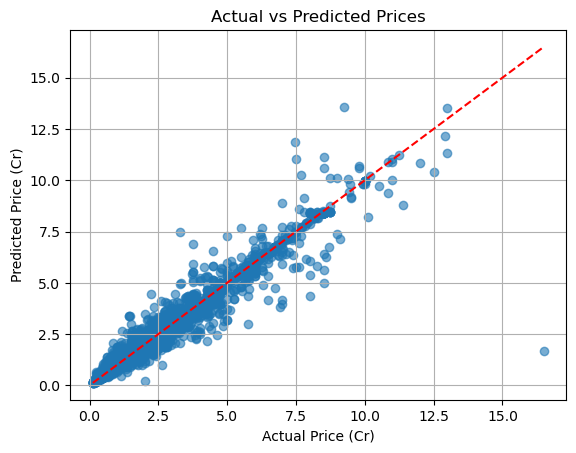

In [24]:
plt.scatter(y_test, predictions, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price (Cr)")
plt.ylabel("Predicted Price (Cr)")
plt.title("Actual vs Predicted Prices")
plt.grid(True)
plt.show()

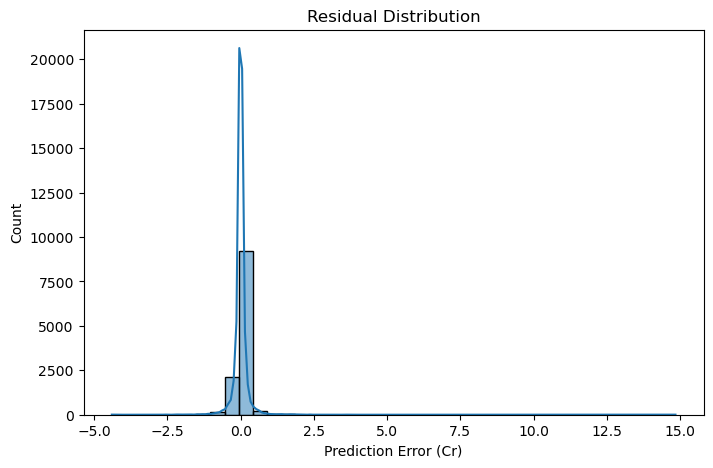

In [25]:
y_pred = grid_search.predict(X_test)
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Prediction Error (Cr)")
plt.show()


In [26]:
import joblib
joblib.dump(best_model, 'mumbai_house_price_model_latest.pkl')

['mumbai_house_price_model_latest.pkl']

<Figure size 1000x600 with 0 Axes>

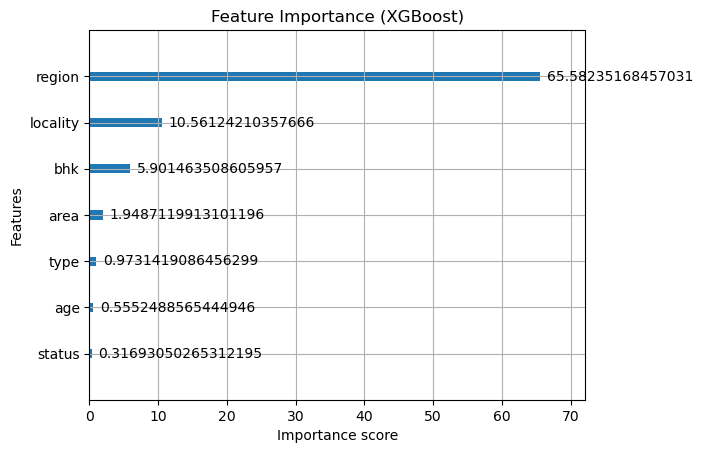

In [27]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plot_importance(best_model, importance_type='gain')
plt.title("Feature Importance (XGBoost)")
plt.show()
